## Global AQI Predictor

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, LSTM, Conv1D, Flatten, Input, LayerNormalization, MultiHeadAttention, Dropout


### Preprocessing

In [40]:
file_path = r"C:\Users\LENOVO\Downloads\AQI and Lat Long of Countries.csv"
df = pd.read_csv(file_path)

In [41]:
print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (16695, 14)
              Country              City  AQI Value AQI Category  CO AQI Value  \
0  Russian Federation        Praskoveya         51     Moderate             1   
1              Brazil  Presidente Dutra         41         Good             1   
2              Brazil  Presidente Dutra         41         Good             1   
3               Italy   Priolo Gargallo         66     Moderate             1   
4              Poland         Przasnysz         34         Good             1   

  CO AQI Category  Ozone AQI Value Ozone AQI Category  NO2 AQI Value  \
0            Good               36               Good              0   
1            Good                5               Good              1   
2            Good                5               Good              1   
3            Good               39               Good              2   
4            Good               34               Good              0   

  NO2 AQI Category  PM2.5 AQI Value PM2.5 AQI Categor

In [42]:
print(df.isnull().sum())

Country               302
City                    0
AQI Value               0
AQI Category            0
CO AQI Value            0
CO AQI Category         0
Ozone AQI Value         0
Ozone AQI Category      0
NO2 AQI Value           0
NO2 AQI Category        0
PM2.5 AQI Value         0
PM2.5 AQI Category      0
lat                     0
lng                     0
dtype: int64


In [43]:
numeric_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(exclude=np.number).columns
print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

# Missing values
print("Missing values per column:\n", df.isnull().sum())

# Fill missing values
# Numeric: mean, Categorical: mode
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])


Numeric columns: Index(['AQI Value', 'CO AQI Value', 'Ozone AQI Value', 'NO2 AQI Value',
       'PM2.5 AQI Value', 'lat', 'lng'],
      dtype='object')
Categorical columns: Index(['Country', 'City', 'AQI Category', 'CO AQI Category',
       'Ozone AQI Category', 'NO2 AQI Category', 'PM2.5 AQI Category'],
      dtype='object')
Missing values per column:
 Country               302
City                    0
AQI Value               0
AQI Category            0
CO AQI Value            0
CO AQI Category         0
Ozone AQI Value         0
Ozone AQI Category      0
NO2 AQI Value           0
NO2 AQI Category        0
PM2.5 AQI Value         0
PM2.5 AQI Category      0
lat                     0
lng                     0
dtype: int64


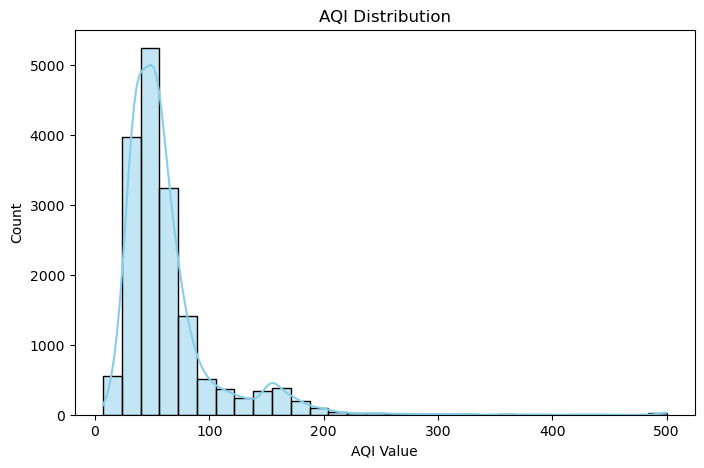

In [44]:
plt.figure(figsize=(8,5))
sns.histplot(df['AQI Value'], bins=30, kde=True, color='skyblue')
plt.title("AQI Distribution")
plt.show()

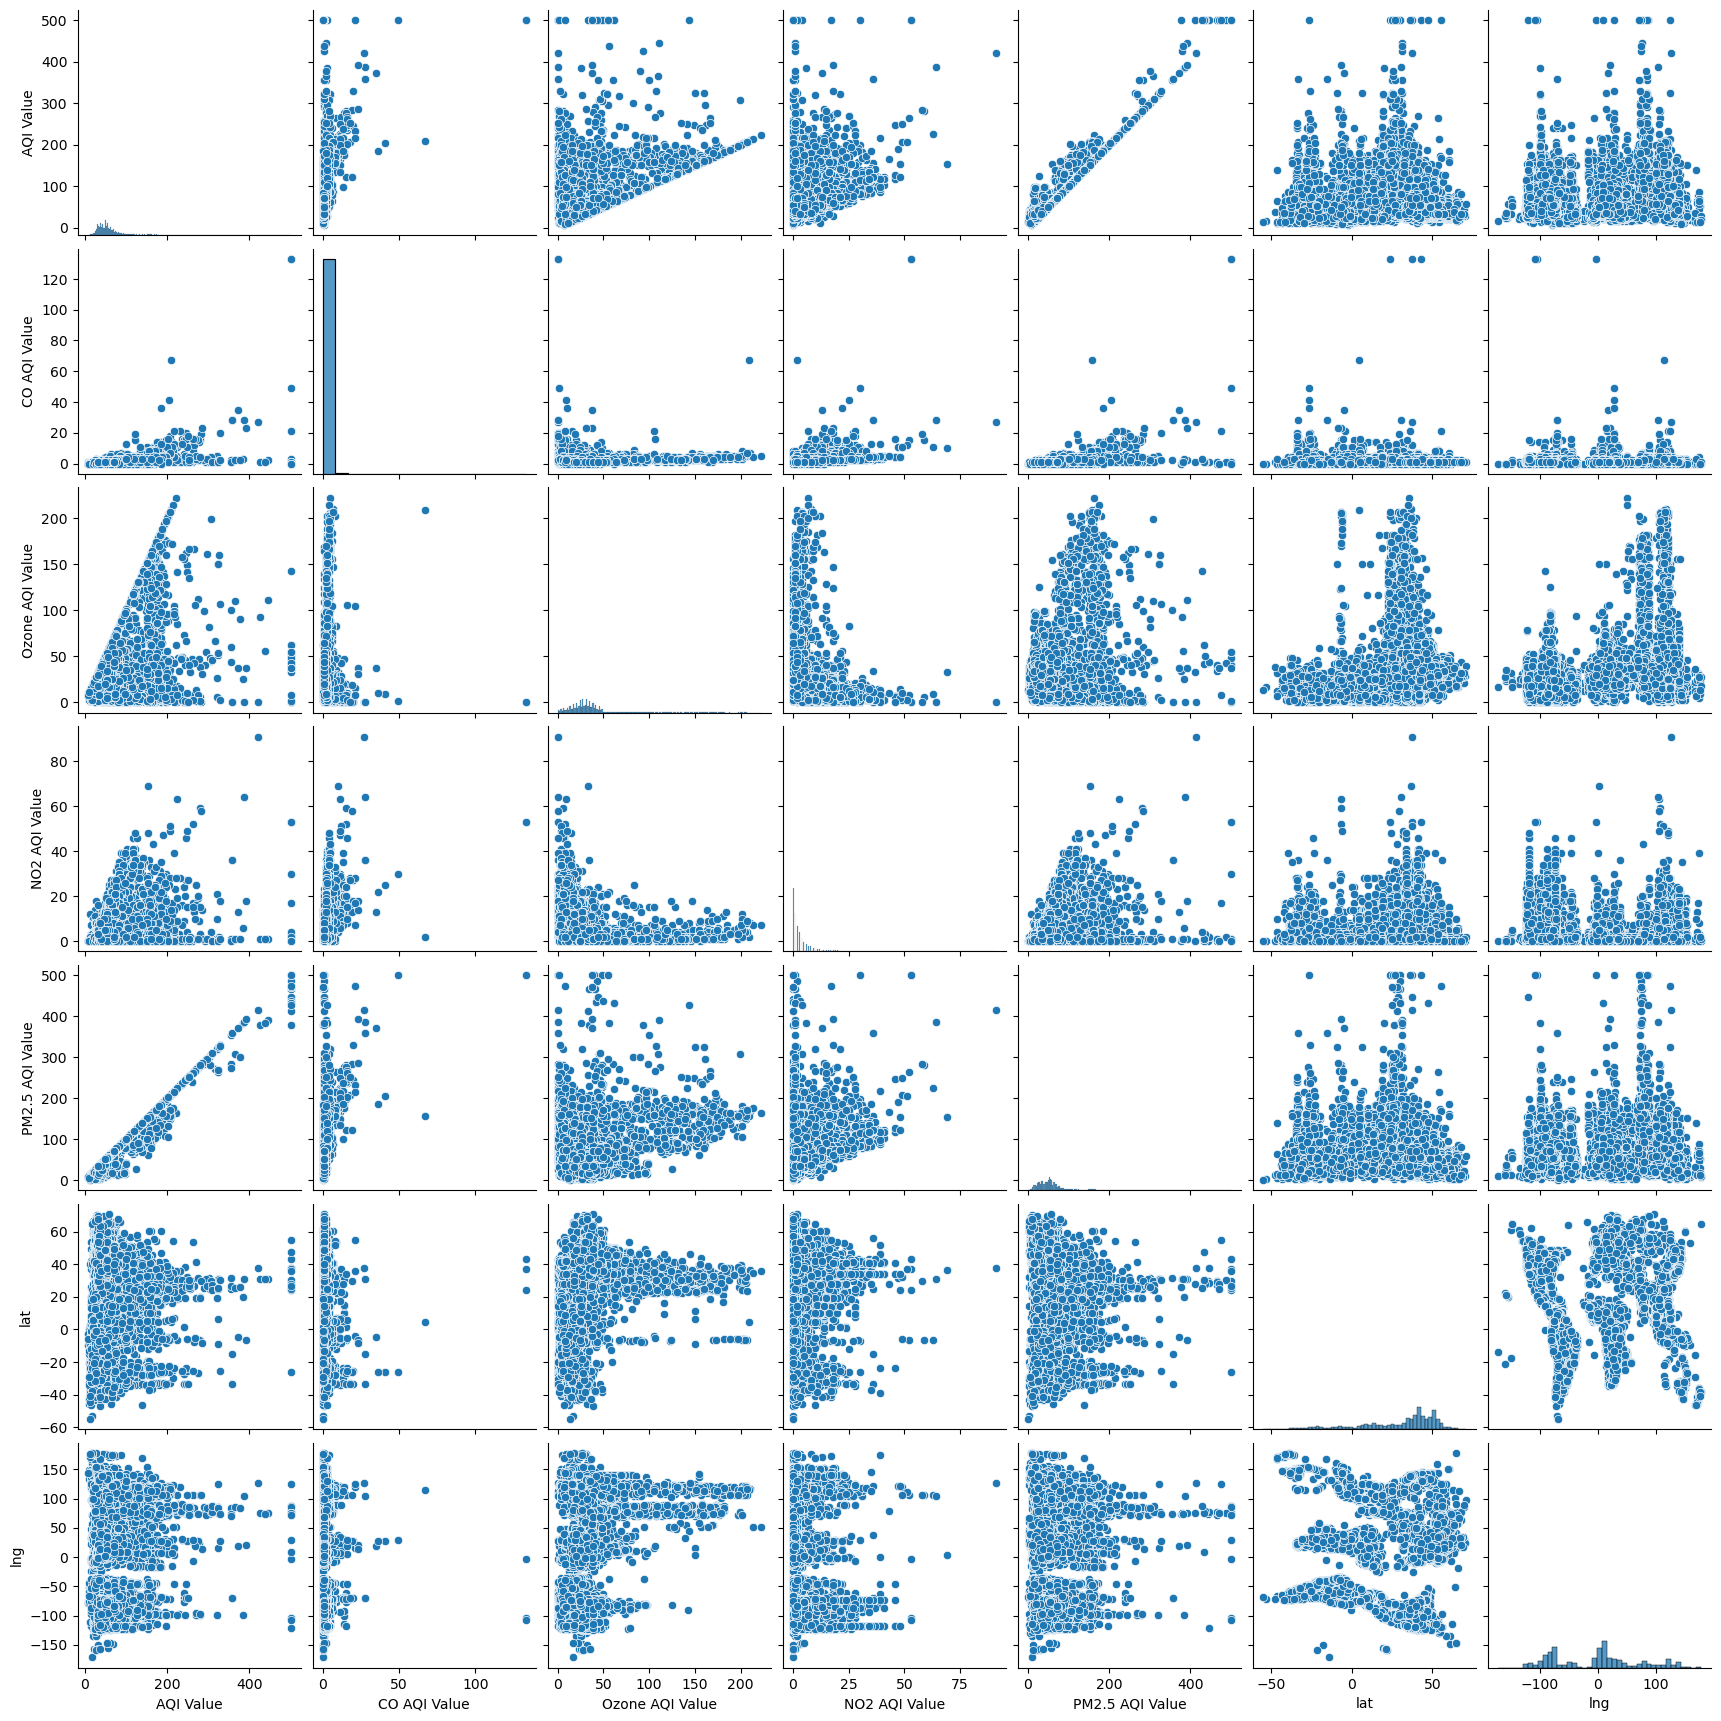

In [45]:
sns.pairplot(df[numeric_cols])
plt.show()


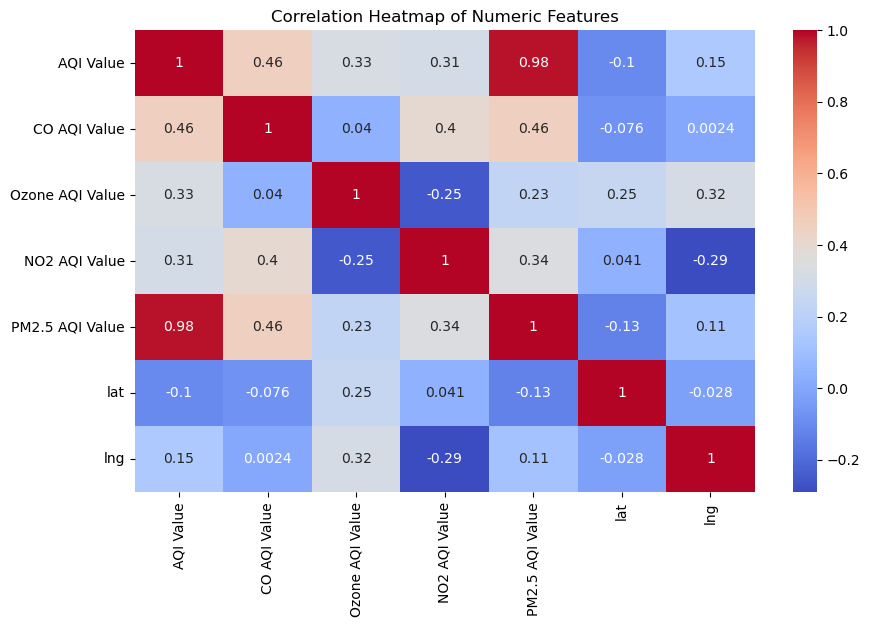

In [46]:
plt.figure(figsize=(10,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

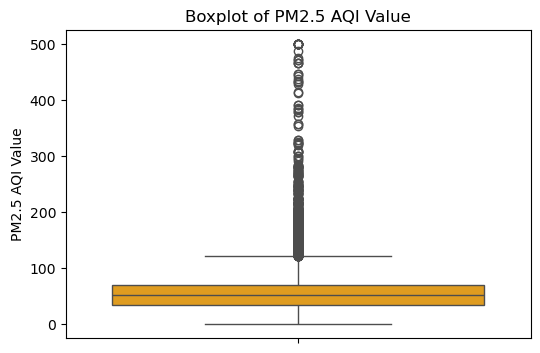

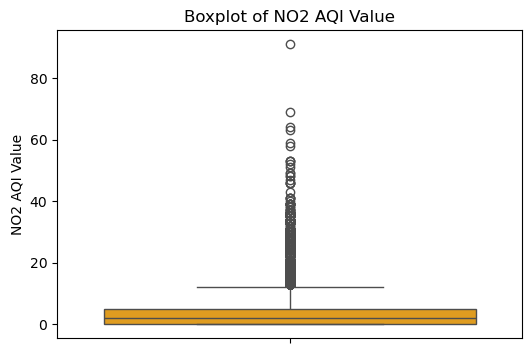

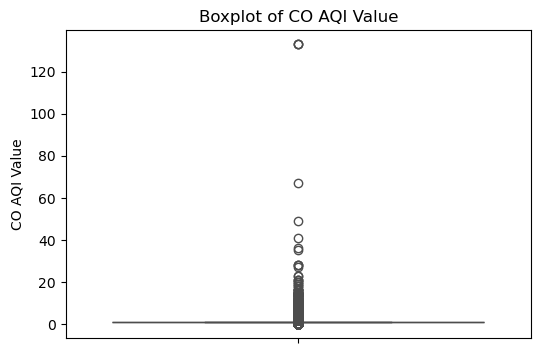

In [47]:
pollutants = ['PM2.5 AQI Value','NO2 AQI Value','CO AQI Value']
for col in pollutants:
    plt.figure(figsize=(6,4))
    sns.boxplot(y=df[col], color='orange')
    plt.title(f"Boxplot of {col}")
    plt.show()

In [48]:
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

target_column = 'AQI Value'

# Features & target
X = df.drop([target_column, 'AQI Category', 'CO AQI Category', 'Ozone AQI Category',
             'NO2 AQI Category', 'PM2.5 AQI Category'], axis=1)
y = df[target_column]


# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

X_train_seq = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_seq = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)



105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Test MSE: 1.97
Test R²: 1.00


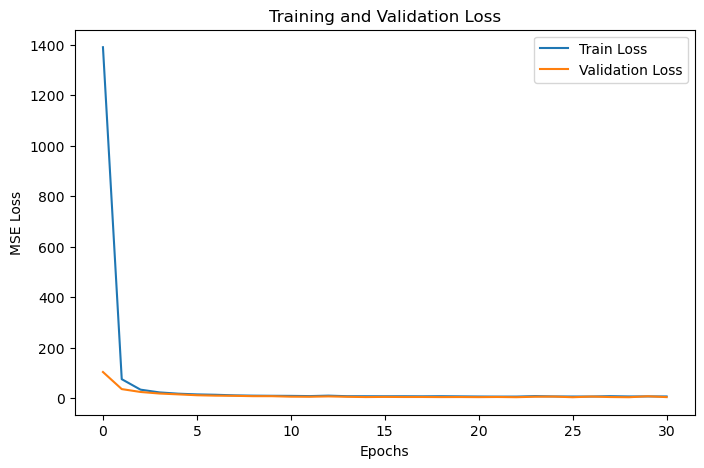

In [49]:
y_pred = model.predict(X_test).flatten()
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Test MSE: {mse:.2f}")
print(f"Test R²: {r2:.2f}")

# Training curves
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

### Model Training

#### LSTM

In [50]:
lstm_model = Sequential([
    LSTM(64, activation='relu', input_shape=(X_train_seq.shape[1], 1)),
    Dense(32, activation='relu'),
    Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
history_lstm = lstm_model.fit(X_train_seq, y_train, validation_split=0.2,
                              epochs=50, batch_size=16, verbose=1)

Epoch 1/50


C:\Users\LENOVO\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


668/668 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 2289.7483 - mae: 27.4607 - val_loss: 829.6034 - val_mae: 21.0159
Epoch 2/50
668/668 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 476.7136 - mae: 13.6208 - val_loss: 115.7148 - val_mae: 6.9303
Epoch 3/50
668/668 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 79.6344 - mae: 5.4541 - val_loss: 95.1899 - val_mae: 6.1596
Epoch 4/50
668/668 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 51.0427 - mae: 4.5003 - val_loss: 53.2475 - val_mae: 4.6352
Epoch 5/50
668/668 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 46.9436 - mae: 4.2536 - val_loss: 57.4171 - val_mae: 5.2945
Epoch 6/50
668/668 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 36.5021 - mae: 3.7807 - val_loss: 23.3811 - val_mae: 2.7117
Epoch 7/50
668/668 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 36.6251 - mae: 3.6694 - val_loss: 19.7390 - val_mae: 2.7271
Epoch 8/50
668/668 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 49.0840 - mae: 4.0915 - val_loss: 81.8930 - val_mae: 7.2416
Epoch 9/50
668/668 ━━━━━━━━━━━━━━━━━━━━ 3s 

105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step   
LSTM MSE: 7.683688163757324
LSTM R2: 0.9953671097755432


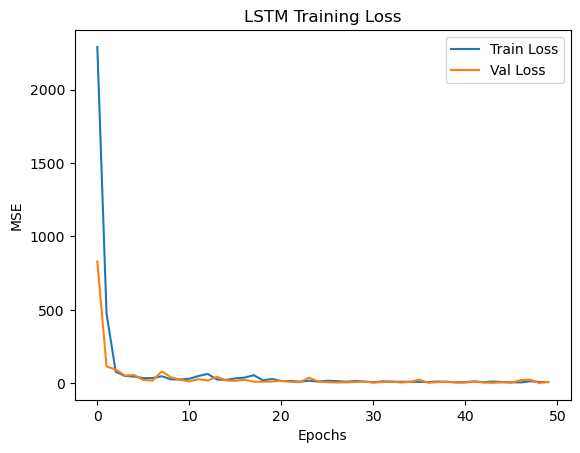

In [51]:
y_pred_lstm = lstm_model.predict(X_test_seq).flatten()
print("LSTM MSE:", mean_squared_error(y_test, y_pred_lstm))
print("LSTM R2:", r2_score(y_test, y_pred_lstm))

plt.plot(history_lstm.history['loss'], label='Train Loss')
plt.plot(history_lstm.history['val_loss'], label='Val Loss')
plt.title("LSTM Training Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.legend()
plt.show()

#### CNN

In [52]:
cnn_model = Sequential([
    Conv1D(64, kernel_size=2, activation='relu', input_shape=(X_train_seq.shape[1], 1)),
    Conv1D(32, kernel_size=2, activation='relu'),
    Flatten(),
    Dense(32, activation='relu'),
    Dense(1)
])
cnn_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
history_cnn = cnn_model.fit(X_train_seq, y_train, validation_split=0.2,
                            epochs=50, batch_size=16, verbose=1)

Epoch 1/50


C:\Users\LENOVO\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


668/668 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 984.3144 - mae: 18.1577 - val_loss: 97.6123 - val_mae: 7.1502
Epoch 2/50
668/668 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 56.3209 - mae: 4.7083 - val_loss: 40.7090 - val_mae: 3.6704
Epoch 3/50
668/668 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 36.9375 - mae: 3.4035 - val_loss: 44.8912 - val_mae: 4.8667
Epoch 4/50
668/668 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 25.1788 - mae: 2.7516 - val_loss: 17.5152 - val_mae: 2.3108
Epoch 5/50
668/668 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 16.2744 - mae: 2.1187 - val_loss: 11.5648 - val_mae: 1.8466
Epoch 6/50
668/668 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 12.1192 - mae: 1.8088 - val_loss: 9.1617 - val_mae: 1.4621
Epoch 7/50
668/668 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 13.2038 - mae: 1.8154 - val_loss: 6.9644 - val_mae: 1.1044
Epoch 8/50
668/668 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 9.3357 - mae: 1.4222 - val_loss: 7.4176 - val_mae: 1.5192
Epoch 9/50
668/668 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step -

105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step   
CNN MSE: 3.795710563659668
CNN R2: 0.9977113604545593


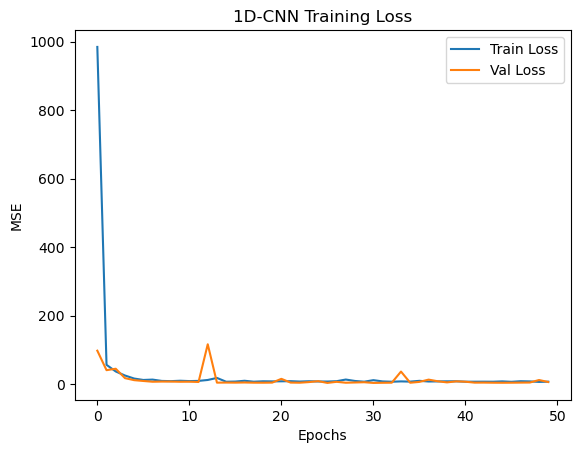

In [53]:
y_pred_cnn = cnn_model.predict(X_test_seq).flatten()
print("CNN MSE:", mean_squared_error(y_test, y_pred_cnn))
print("CNN R2:", r2_score(y_test, y_pred_cnn))

plt.plot(history_cnn.history['loss'], label='Train Loss')
plt.plot(history_cnn.history['val_loss'], label='Val Loss')
plt.title("1D-CNN Training Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.legend()
plt.show()

#### Transformer Model

In [54]:
inputs = Input(shape=(X_train.shape[1], 1))
x = LayerNormalization()(inputs)
x = MultiHeadAttention(num_heads=2, key_dim=4)(x, x)
x = Flatten()(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.2)(x)
x = Dense(32, activation='relu')(x)
outputs = Dense(1)(x)

transformer_model = Model(inputs=inputs, outputs=outputs)
transformer_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
history_trans = transformer_model.fit(X_train_seq, y_train, validation_split=0.2,
                                     epochs=50, batch_size=16, verbose=1)

Epoch 1/50
668/668 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 5977.1387 - mae: 63.3549 - val_loss: 5528.0884 - val_mae: 62.0929
Epoch 2/50
668/668 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 5894.8076 - mae: 62.7010 - val_loss: 5447.4658 - val_mae: 61.4402
Epoch 3/50
668/668 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 5813.4214 - mae: 62.0510 - val_loss: 5367.7974 - val_mae: 60.7883
Epoch 4/50
668/668 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 5732.9839 - mae: 61.4003 - val_loss: 5289.0825 - val_mae: 60.1375
Epoch 5/50
668/668 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 5653.5630 - mae: 60.7499 - val_loss: 5211.3501 - val_mae: 59.4877
Epoch 6/50
668/668 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 5575.1948 - mae: 60.1003 - val_loss: 5134.6875 - val_mae: 58.8399
Epoch 7/50
668/668 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 5497.8364 - mae: 59.4541 - val_loss: 5058.9834 - val_mae: 58.1929
Epoch 8/50
668/668 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 5421.3213 - mae: 58.8063 - val_loss: 4984.2051 - val_mae: 

105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step   
Transformer MSE: 2508.60595703125
Transformer R2: -0.5125604867935181


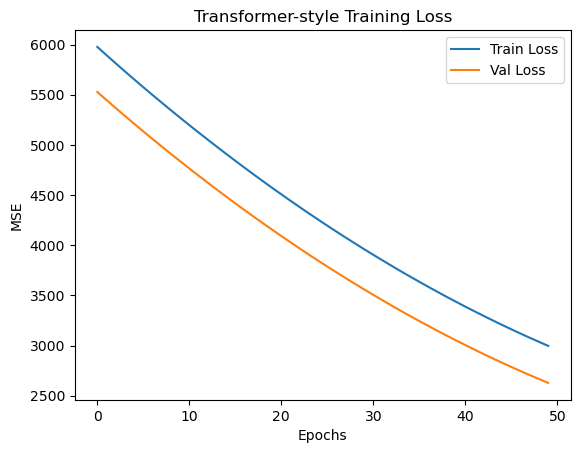

In [55]:
y_pred_trans = transformer_model.predict(X_test_seq).flatten()
print("Transformer MSE:", mean_squared_error(y_test, y_pred_trans))
print("Transformer R2:", r2_score(y_test, y_pred_trans))

plt.plot(history_trans.history['loss'], label='Train Loss')
plt.plot(history_trans.history['val_loss'], label='Val Loss')
plt.title("Transformer-style Training Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.legend()
plt.show()

In [56]:
models = ['LSTM', '1D-CNN', 'Transformer']
mse_values = [mean_squared_error(y_test, y_pred_lstm),
              mean_squared_error(y_test, y_pred_cnn),
              mean_squared_error(y_test, y_pred_trans)]
r2_values = [r2_score(y_test, y_pred_lstm),
             r2_score(y_test, y_pred_cnn),
             r2_score(y_test, y_pred_trans)]

### Model saving

In [58]:
transformer_model.save("aqi_transformer_model.h5")
print("Best model saved as aqi_transformer_model.h5")


Best model saved as aqi_transformer_model.h5


In [61]:
from tensorflow.keras.models import load_model

model = load_model("aqi_transformer_model.h5", compile=False)
